# Chronos-2 Profiling

Profiles the Chronos-2 model using MASE's statistical profiler pass.

**What this notebook does:**
1. Loads the pretrained Chronos-2 model
2. Traces it into a `MaseGraph` and runs metadata passes
3. Inspects graph structure: node types, op counts, shapes
4. Runs the statistical profiler to collect weight & activation statistics
5. Visualises distributions, outlier ratios, and per-layer summaries

**Useful for:** understanding which layers have large weight ranges (important for quantization),
which activations have outliers (important for SmoothQuant / AWQ), and overall model complexity.

## 1. Imports & config

In [5]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

os.environ.setdefault('HOME', os.environ.get('USERPROFILE', str(Path.home())))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE    = 2      # batch size for activation profiling
NUM_SAMPLES   = 8      # total samples for activation profiling (increase for more stable stats)
OUTPUT_DIR    = Path('artifacts/profiling')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')
print(f'Profiling with {NUM_SAMPLES} samples (batch={BATCH_SIZE})')

Device: cpu
Profiling with 8 samples (batch=2)


## 2. Load Chronos-2 model

In [6]:
from chop.models import get_model

model = get_model('chronos-2', pretrained=True)
model.eval()
model = model.to(DEVICE)

# Force eager attention so FX tracing sees the individual matmul/softmax nodes
# (rather than a fused SDPA call that FX cannot decompose)
if hasattr(model.config, '_attn_implementation'):
    model.config._attn_implementation = 'eager'

chronos_cfg = model.config.chronos_config
C_LEN       = chronos_cfg['context_length']       # 8192
OUT_PATCH   = chronos_cfg['output_patch_size']     # 16

print('Model loaded:', type(model).__name__)
print('Context length:', C_LEN)
print('Output patch size:', OUT_PATCH)
print('\nChronos config:')
for k, v in chronos_cfg.items():
    print(f'  {k}: {v}')

Model loaded: Chronos2Model
Context length: 8192
Output patch size: 16

Chronos config:
  context_length: 8192
  input_patch_size: 16
  input_patch_stride: 16
  max_output_patches: 64
  output_patch_size: 16
  quantiles: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
  time_encoding_scale: 8192
  use_arcsinh: True
  use_reg_token: True


## 3. Build MaseGraph & run metadata passes

In [7]:
from chop import MaseGraph
import chop.passes as passes

dummy_in = {
    'context':           torch.randn((BATCH_SIZE, C_LEN), device=DEVICE),
    'group_ids':         torch.zeros((BATCH_SIZE,), dtype=torch.long, device=DEVICE),
    'future_covariates': torch.zeros((BATCH_SIZE, OUT_PATCH), device=DEVICE),
    'num_output_patches': 1,
}

mg = MaseGraph(
    model,
    hf_input_names=['context', 'group_ids', 'future_covariates', 'num_output_patches'],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg, pass_args={'dummy_in': dummy_in})
mg, _ = passes.add_software_metadata_analysis_pass(mg)

all_nodes = list(mg.fx_graph.nodes)
print(f'Graph nodes: {len(all_nodes)}')

`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.


tensor([[ 0.0420, -1.3162, -0.5972,  ...,  2.1908,  0.9738, -1.0709],
        [ 0.0171,  1.5448, -2.7040,  ...,  1.7442, -0.7287,  0.2030]])
tensor([[ 0.0420, -1.3162, -0.5972,  ...,  2.1908,  0.9738, -1.0709],
        [ 0.0171,  1.5448, -2.7040,  ...,  1.7442, -0.7287,  0.2030]])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])
tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]])
tensor([[ 0.0420, -1.3162, -0.5972,  ...,  2.1908,  0.9738, -1.0709],
        [ 0.0171,  1.5448, -2.7040,  ...,  1.7442, -0.7287,  0.2030]])
tensor([[ 0.0420, -1.3162, -0.5972,  ...,  2.1908,  0.9738, -1.0709],
        [ 0.0171,  1.5448, -2.7040,  ...,  1.7442, -0.7287,  0.2030]])
tensor([[ 0.0229, -1.3354, -0.6163,  ...,  2.1717,  0.9546, -1.0900],
        [ 0.0116,  1.5394, -2.7094,  ...,  1.7388, -0.7341,  0.1976]])
tensor([[5.2269e-04, 1.7832e+00, 3.7982e-01,  ..., 4.7162e+00, 9.1132e-01

WARNING  mase_type `builtin_func`, mase_op `getitem` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `builtin_func`, mase_op `getitem` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `builtin_func`, mase_op `isnan` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `implicit_func`, mase_op `logical_not` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `implicit_func`, mase_op `to` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `builtin_func`, mase_op `getitem` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `builtin_func`, mase_op `getitem` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `implicit_func`, mase_op `to` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default anal

tensor([[[[ 0.1515,  0.0925, -0.0768,  ..., -0.0286,  0.0956, -0.0229],
          [ 0.1680,  0.0743, -0.0832,  ..., -0.0016,  0.0872, -0.0130]],

         [[ 0.0995, -0.0561, -0.0455,  ...,  0.0250, -0.0474, -0.1270],
          [ 0.0976, -0.0602, -0.0450,  ...,  0.0267, -0.0427, -0.1287]],

         [[-0.0059,  0.1647,  0.1787,  ..., -0.1821, -0.0444, -0.0456],
          [-0.0050,  0.1638,  0.1791,  ..., -0.1821, -0.0440, -0.0462]],

         ...,

         [[-0.0035, -0.0454, -0.0480,  ..., -0.0330,  0.0058, -0.0462],
          [-0.0034, -0.0459, -0.0471,  ..., -0.0331,  0.0060, -0.0457]],

         [[ 0.0244, -0.1383,  0.0496,  ...,  0.0391, -0.0274,  0.1250],
          [ 0.0221, -0.1401,  0.0527,  ...,  0.0358, -0.0257,  0.1249]],

         [[-0.0088, -0.0595, -0.0540,  ..., -0.0204, -0.0898, -0.1077],
          [-0.0084, -0.0593, -0.0539,  ..., -0.0206, -0.0898, -0.1076]]],


        [[[ 0.1296,  0.0422, -0.0393,  ..., -0.0336,  0.0922, -0.0336],
          [ 0.1417,  0.0339, -0.039

WARNING  mase_type `implicit_func`, mase_op `pow` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `implicit_func`, mase_op `mean` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `builtin_func`, mase_op `sqrt` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `implicit_func`, mase_op `eq` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `implicit_func`, mase_op `eq` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `builtin_func`, mase_op `getitem` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `builtin_func`, mase_op `getitem` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer
WARNING  mase_type `builtin_func`, mase_op `getitem` not found in SOFTWARE_PARAM_ANALYSIS_LAYERS. Using default analysis layer


Graph nodes: 2034


## 4. Graph structure overview

In [8]:
from collections import Counter
from chop.passes.graph.utils import get_mase_op, get_mase_type

# ── Count ops by FX op kind ───────────────────────────────────────────────────
fx_op_counts = Counter(n.op for n in all_nodes)
print('FX op kinds:')
for op, cnt in sorted(fx_op_counts.items(), key=lambda x: -x[1]):
    print(f'  {op:30s}  {cnt}')

# ── Count by MASE op type ─────────────────────────────────────────────────────
mase_op_counts = Counter()
for n in all_nodes:
    try:
        mase_op_counts[get_mase_op(n)] += 1
    except Exception:
        mase_op_counts['<unknown>'] += 1

print('\nTop 20 MASE ops:')
for op, cnt in mase_op_counts.most_common(20):
    print(f'  {str(op):35s}  {cnt}')

FX op kinds:
  call_function                   973
  call_method                     809
  call_module                     198
  get_attr                        49
  placeholder                     4
  output                          1

Top 20 MASE ops:
  getitem                              363
  size                                 284
  transpose                            132
  mul                                  129
  linear                               129
  add                                  101
  to                                   92
  getattr                              84
  view                                 79
  eq                                   76
  dropout                              53
  div                                  52
  constant                             49
  float                                48
  cat                                  42
  mean                                 38
  sqrt                                 38
  pow                     

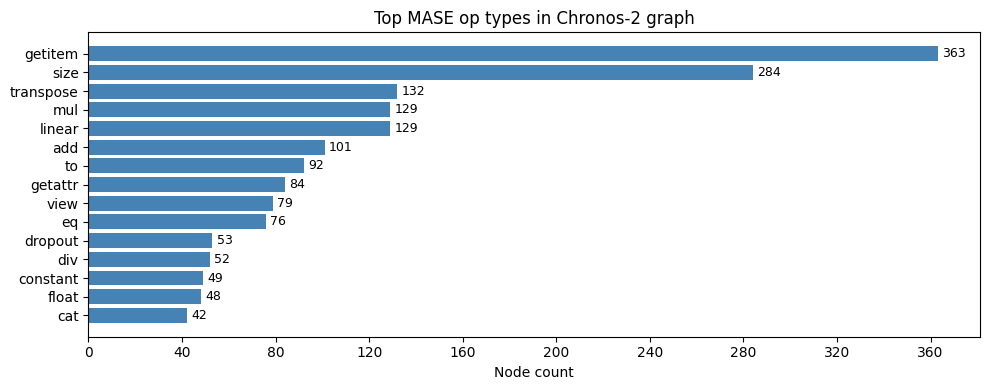

Saved op_frequency.png


In [9]:
# ── Bar chart of MASE op frequencies ─────────────────────────────────────────
top_ops = mase_op_counts.most_common(15)
labels  = [str(op) for op, _ in top_ops]
counts  = [cnt for _, cnt in top_ops]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels[::-1], counts[::-1], color='steelblue')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Node count')
ax.set_title('Top MASE op types in Chronos-2 graph')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'op_frequency.png', dpi=150)
plt.show()
print('Saved op_frequency.png')

## 5. Parameter count & size

In [10]:
total_params   = sum(p.numel() for p in model.parameters())
trainable      = sum(p.numel() for p in model.parameters() if p.requires_grad)
size_fp32_mb   = total_params * 4 / 1024**2
size_fp16_mb   = total_params * 2 / 1024**2
size_int8_mb   = total_params * 1 / 1024**2

print(f'Total parameters:        {total_params:>12,}')
print(f'Trainable parameters:    {trainable:>12,}')
print(f'Model size (FP32):       {size_fp32_mb:>10.1f} MB')
print(f'Model size (FP16/BF16):  {size_fp16_mb:>10.1f} MB')
print(f'Model size (INT8):       {size_int8_mb:>10.1f} MB')

# ── Per-submodule param counts ────────────────────────────────────────────────
rows = []
for name, module in model.named_modules():
    own_params = sum(p.numel() for p in module.parameters(recurse=False))
    if own_params > 0:
        rows.append({'module': name or '(root)', 'params': own_params,
                     'size_MB': own_params * 4 / 1024**2})

param_df = pd.DataFrame(rows).sort_values('params', ascending=False)
print(f'\nTop 20 submodules by parameter count:')
print(param_df.head(20).to_string(index=False))

Total parameters:         119,477,664
Trainable parameters:     119,477,664
Model size (FP32):            455.8 MB
Model size (FP16/BF16):       227.9 MB
Model size (INT8):            113.9 MB

Top 20 submodules by parameter count:
                             module  params  size_MB
output_patch_embedding.hidden_layer 2362368 9.011719
 input_patch_embedding.output_layer 2360064 9.002930
     encoder.block.0.layer.2.mlp.wo 2359296 9.000000
     encoder.block.1.layer.2.mlp.wo 2359296 9.000000
     encoder.block.1.layer.2.mlp.wi 2359296 9.000000
     encoder.block.7.layer.2.mlp.wo 2359296 9.000000
     encoder.block.8.layer.2.mlp.wi 2359296 9.000000
     encoder.block.7.layer.2.mlp.wi 2359296 9.000000
     encoder.block.9.layer.2.mlp.wi 2359296 9.000000
    encoder.block.10.layer.2.mlp.wi 2359296 9.000000
     encoder.block.6.layer.2.mlp.wi 2359296 9.000000
     encoder.block.6.layer.2.mlp.wo 2359296 9.000000
     encoder.block.3.layer.2.mlp.wi 2359296 9.000000
     encoder.block.5.layer

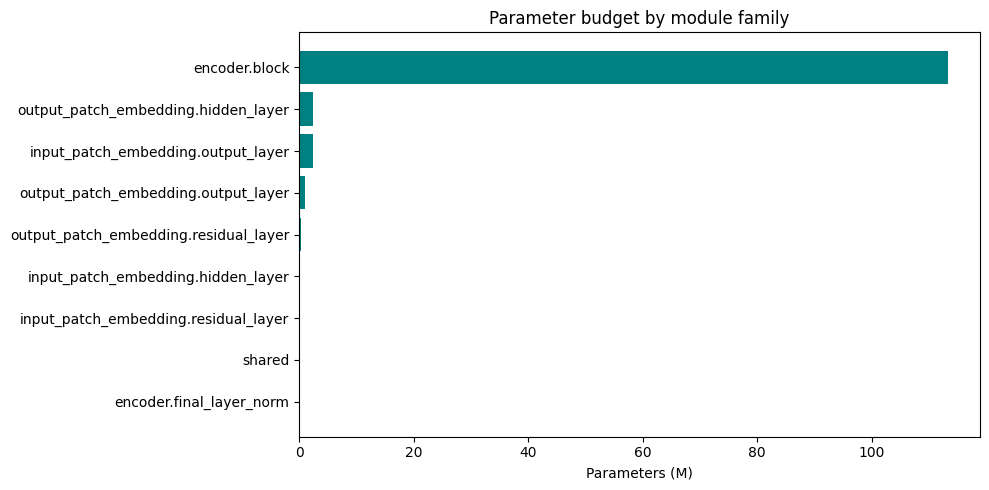

In [11]:
# ── Treemap-style bar: parameter budget by module family ─────────────────────
def module_family(name):
    parts = name.split('.')
    # Group by top-2 levels
    return '.'.join(parts[:2]) if len(parts) >= 2 else parts[0]

family_params = {}
for _, row in param_df.iterrows():
    fam = module_family(row['module'])
    family_params[fam] = family_params.get(fam, 0) + row['params']

fam_sorted = sorted(family_params.items(), key=lambda x: -x[1])[:15]
fam_labels = [f[0] for f in fam_sorted]
fam_counts = [f[1] / 1e6 for f in fam_sorted]  # in millions

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(fam_labels[::-1], fam_counts[::-1], color='teal')
ax.set_xlabel('Parameters (M)')
ax.set_title('Parameter budget by module family')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'param_budget.png', dpi=150)
plt.show()

## 6. Activation shape inspection (from common metadata)

In [12]:
# Dump the input/output shapes for every call_module node
shape_rows = []
for node in mg.fx_graph.nodes:
    if node.op != 'call_module':
        continue
    try:
        mase_meta = node.meta['mase']
        common    = mase_meta.parameters.get('common', {})
        args_meta = common.get('args', {})
        results   = common.get('results', {})

        in_shapes  = {k: v.get('shape') for k, v in args_meta.items()
                      if isinstance(v, dict) and v.get('shape') is not None}
        out_shapes = {k: v.get('shape') for k, v in results.items()
                      if isinstance(v, dict) and v.get('shape') is not None}

        shape_rows.append({
            'node':       node.name,
            'target':     node.target,
            'mase_op':    get_mase_op(node),
            'in_shapes':  str(in_shapes),
            'out_shapes': str(out_shapes),
        })
    except Exception:
        pass

shape_df = pd.DataFrame(shape_rows)
print(f'call_module nodes with shape metadata: {len(shape_df)}')
shape_df.head(20)

call_module nodes with shape metadata: 198


,node,target,mase_op,in_shapes,out_shapes
0,input_patch_embedding_hidden_layer,input_patch_embedding.hidden_layer,linear,"{'data_in_0': [2, 512, 48], 'weight': [3072, 4...","{'data_out_0': [2, 512, 3072]}"
1,input_patch_embedding_act,input_patch_embedding.act,relu,"{'data_in_0': [2, 512, 3072]}","{'data_out_0': [2, 512, 3072]}"
2,input_patch_embedding_output_layer,input_patch_embedding.output_layer,linear,"{'data_in_0': [2, 512, 3072], 'weight': [768, ...","{'data_out_0': [2, 512, 768]}"
3,input_patch_embedding_dropout,input_patch_embedding.dropout,dropout,"{'data_in_0': [2, 512, 768]}","{'data_out_0': [2, 512, 768]}"
4,input_patch_embedding_residual_layer,input_patch_embedding.residual_layer,linear,"{'data_in_0': [2, 512, 48], 'weight': [768, 48...","{'data_out_0': [2, 512, 768]}"
5,shared,shared,embedding,"{'data_in_0': [2, 1], 'weight': [2, 768]}","{'data_out_0': [2, 1, 768]}"
6,input_patch_embedding_hidden_layer_1,input_patch_embedding.hidden_layer,linear,"{'data_in_0': [2, 1, 48], 'weight': [3072, 48]...","{'data_out_0': [2, 1, 3072]}"
7,input_patch_embedding_act_1,input_patch_embedding.act,relu,"{'data_in_0': [2, 1, 3072]}","{'data_out_0': [2, 1, 3072]}"
8,input_patch_embedding_output_layer_1,input_patch_embedding.output_layer,linear,"{'data_in_0': [2, 1, 3072], 'weight': [768, 30...","{'data_out_0': [2, 1, 768]}"
9,input_patch_embedding_dropout_1,input_patch_embedding.dropout,dropout,"{'data_in_0': [2, 1, 768]}","{'data_out_0': [2, 1, 768]}"


## 7. Statistical profiling

Collects per-node statistics for **weights** (without needing data) and **activations** (using synthetic inputs).

Statistics collected:
- `range_min_max` — min / max of weights and activations  
- `abs_mean` — mean absolute value (proxy for magnitude)  
- `variance_precise` — exact variance  
- `range_quantile` — 1st / 99th percentile (outlier detection)

In [13]:
# ── Minimal input generator compatible with ActProfiler ──────────────────────
class Chronos2InputGenerator:
    """Yields synthetic Chronos-2 input dicts for activation profiling."""
    def __init__(self, batch_size, c_len, out_patch, device='cpu'):
        self.batch_size = batch_size
        self.c_len      = c_len
        self.out_patch  = out_patch
        self.device     = device

    def __iter__(self):
        return self

    def __next__(self):
        return {
            'context':           torch.randn(self.batch_size, self.c_len, device=self.device),
            'group_ids':         torch.zeros(self.batch_size, dtype=torch.long, device=self.device),
            'future_covariates': torch.zeros(self.batch_size, self.out_patch, device=self.device),
            'num_output_patches': 1,
        }

input_gen = Chronos2InputGenerator(
    batch_size=BATCH_SIZE,
    c_len=C_LEN,
    out_patch=OUT_PATCH,
    device=DEVICE,
)
print('Input generator ready')

Input generator ready


In [14]:
profile_args = {
    'by': 'type',
    # Profile weights + activations for these MASE op types
    'target_weight_nodes':     ['linear'],
    'target_activation_nodes': ['linear', 'matmul', 'layer_norm'],
    'weight_statistics': {
        'range_min_max':   {'abs': False, 'dims': 'all'},
        'abs_mean':        {'dims': 'all'},
        'variance_precise':{'device': DEVICE, 'dims': 'all'},
        'range_quantile':  {'quantile': 0.99, 'dims': 'all'},
    },
    'activation_statistics': {
        'range_min_max':   {'abs': False, 'dims': 'all'},
        'abs_mean':        {'dims': 'all'},
        'variance_precise':{'device': DEVICE, 'dims': 'all'},
        'range_quantile':  {'quantile': 0.99, 'dims': 'all'},
    },
    'input_generator':          input_gen,
    'num_samples':              NUM_SAMPLES,
    'profile_output_activation': False,
}

print('Running statistical profiler...')
mg, _ = passes.profile_statistics_analysis_pass(mg, pass_args=profile_args)
print('Profiling complete.')

Running statistical profiler...


Profiling act statistics: 100%|██████████| 4/4 [00:37<00:00,  9.48s/it]


Profiling complete.


## 8. Extract & display profiling results

In [15]:
# ── Helper: flatten stats from a node entry ───────────────────────────────────
def extract_scalar(stat_dict, stat_name, key):
    """Pull a scalar value from nested stat dict, return NaN if missing."""
    try:
        val = stat_dict[stat_name][key]
        if isinstance(val, (list, tuple)):
            val = val[0] if len(val) == 1 else val
        return float(val) if not isinstance(val, (list, tuple)) else float(val[0])
    except Exception:
        return float('nan')

# ── Collect per-node rows ─────────────────────────────────────────────────────
rows = []
for node in mg.fx_graph.nodes:
    try:
        sw_args = node.meta['mase'].parameters['software'].get('args', {})
    except Exception:
        continue

    for entry, s_meta in sw_args.items():
        stat = s_meta.get('stat')
        if not isinstance(stat, dict) or not stat:
            continue

        kind = 'weight' if 'data_in' not in entry else 'activation'

        rows.append({
            'node':        node.name,
            'target':      getattr(node, 'target', ''),
            'mase_op':     get_mase_op(node),
            'entry':       entry,
            'kind':        kind,
            'w_min':       extract_scalar(stat, 'range_min_max', 'min'),
            'w_max':       extract_scalar(stat, 'range_min_max', 'max'),
            'abs_mean':    extract_scalar(stat, 'abs_mean', 'abs_mean'),
            'variance':    extract_scalar(stat, 'variance_precise', 'variance'),
            'q01':         extract_scalar(stat, 'range_quantile', 'min'),
            'q99':         extract_scalar(stat, 'range_quantile', 'max'),
        })

prof_df = pd.DataFrame(rows)
prof_df['range'] = prof_df['w_max'] - prof_df['w_min']
prof_df['std']   = prof_df['variance'].apply(lambda v: v**0.5 if v >= 0 else float('nan'))

print(f'Collected stats for {len(prof_df)} (node, entry) pairs')
print(f"  weights:     {(prof_df['kind']=='weight').sum()}")
print(f"  activations: {(prof_df['kind']=='activation').sum()}")
prof_df.head(10)

Collected stats for 291 (node, entry) pairs
  weights:     138
  activations: 153


,node,target,mase_op,entry,kind,w_min,w_max,abs_mean,variance,q01,q99,range,std
0,input_patch_embedding_hidden_layer,input_patch_embedding.hidden_layer,linear,data_in_0,activation,-2.221895,2.149751,0.723886,0.627850,-1.391525,1.385941,4.371646,0.792370
1,input_patch_embedding_hidden_layer,input_patch_embedding.hidden_layer,linear,weight,weight,-0.133290,0.164574,0.005855,0.000137,-0.035888,0.034604,0.297864,0.011699
2,input_patch_embedding_hidden_layer,input_patch_embedding.hidden_layer,linear,bias,weight,-0.221567,0.166635,0.052750,0.002970,-0.178005,0.029986,0.388202,0.054500
3,input_patch_embedding_output_layer,input_patch_embedding.output_layer,linear,data_in_0,activation,0.000000,0.419533,0.006149,0.000413,0.000000,0.096161,0.419533,0.020318
4,input_patch_embedding_output_layer,input_patch_embedding.output_layer,linear,weight,weight,-0.162519,0.177634,0.007638,0.000119,-0.029381,0.029711,0.340153,0.010915
5,input_patch_embedding_output_layer,input_patch_embedding.output_layer,linear,bias,weight,-0.165249,0.186952,0.019425,0.000950,-0.095408,0.088691,0.352200,0.030825
6,input_patch_embedding_residual_layer,input_patch_embedding.residual_layer,linear,data_in_0,activation,-2.221895,2.149751,0.723886,0.627850,-1.391525,1.385941,4.371646,0.792370
7,input_patch_embedding_residual_layer,input_patch_embedding.residual_layer,linear,weight,weight,-0.068968,0.077765,0.003291,0.000041,-0.020792,0.020975,0.146733,0.006375
8,input_patch_embedding_residual_layer,input_patch_embedding.residual_layer,linear,bias,weight,-0.495987,0.212964,0.010861,0.001498,-0.085314,0.070389,0.708951,0.038698
9,input_patch_embedding_hidden_layer_1,input_patch_embedding.hidden_layer,linear,data_in_0,activation,-0.017573,1.000000,0.336750,0.222850,-0.017573,1.000000,1.017573,0.472070


In [16]:
# ── Save full table to CSV ────────────────────────────────────────────────────
csv_path = OUTPUT_DIR / 'profiling_stats.csv'
prof_df.to_csv(csv_path, index=False)
print(f'Saved full stats table: {csv_path}')

Saved full stats table: artifacts\profiling\profiling_stats.csv


## 9. Weight statistics visualisation

In [17]:
weight_df = prof_df[prof_df['kind'] == 'weight'].dropna(subset=['w_min', 'w_max']).copy()
weight_df = weight_df.sort_values('range', ascending=False)

print(f'Weight entries: {len(weight_df)}')
print('\nTop 10 layers by weight range (min/max spread):')
print(weight_df[['node', 'entry', 'w_min', 'w_max', 'range', 'std', 'abs_mean']]
      .head(10).to_string(index=False))

Weight entries: 138

Top 10 layers by weight range (min/max spread):
                                 node  entry     w_min    w_max    range      std  abs_mean
  output_patch_embedding_output_layer weight -0.859825 0.740675 1.600500 0.053515  0.016706
  output_patch_embedding_hidden_layer   bias -1.137462 0.372534 1.509996 0.254479  0.193541
       encoder_block_9_layer_2_mlp_wo weight -0.752233 0.721566 1.473799 0.013341  0.009549
output_patch_embedding_residual_layer   bias -0.517833 0.619359 1.137192 0.206068  0.139761
       encoder_block_4_layer_2_mlp_wo weight -0.775904 0.270917 1.046821 0.008774  0.004951
       encoder_block_3_layer_2_mlp_wo weight -0.666714 0.257416 0.924131 0.008624  0.004763
       encoder_block_1_layer_2_mlp_wo weight -0.613878 0.293143 0.907021 0.009240  0.005651
  output_patch_embedding_hidden_layer weight -0.517638 0.377074 0.894711 0.012647  0.006009
       encoder_block_2_layer_2_mlp_wo weight -0.583906 0.309998 0.893904 0.009787  0.006183
      encod

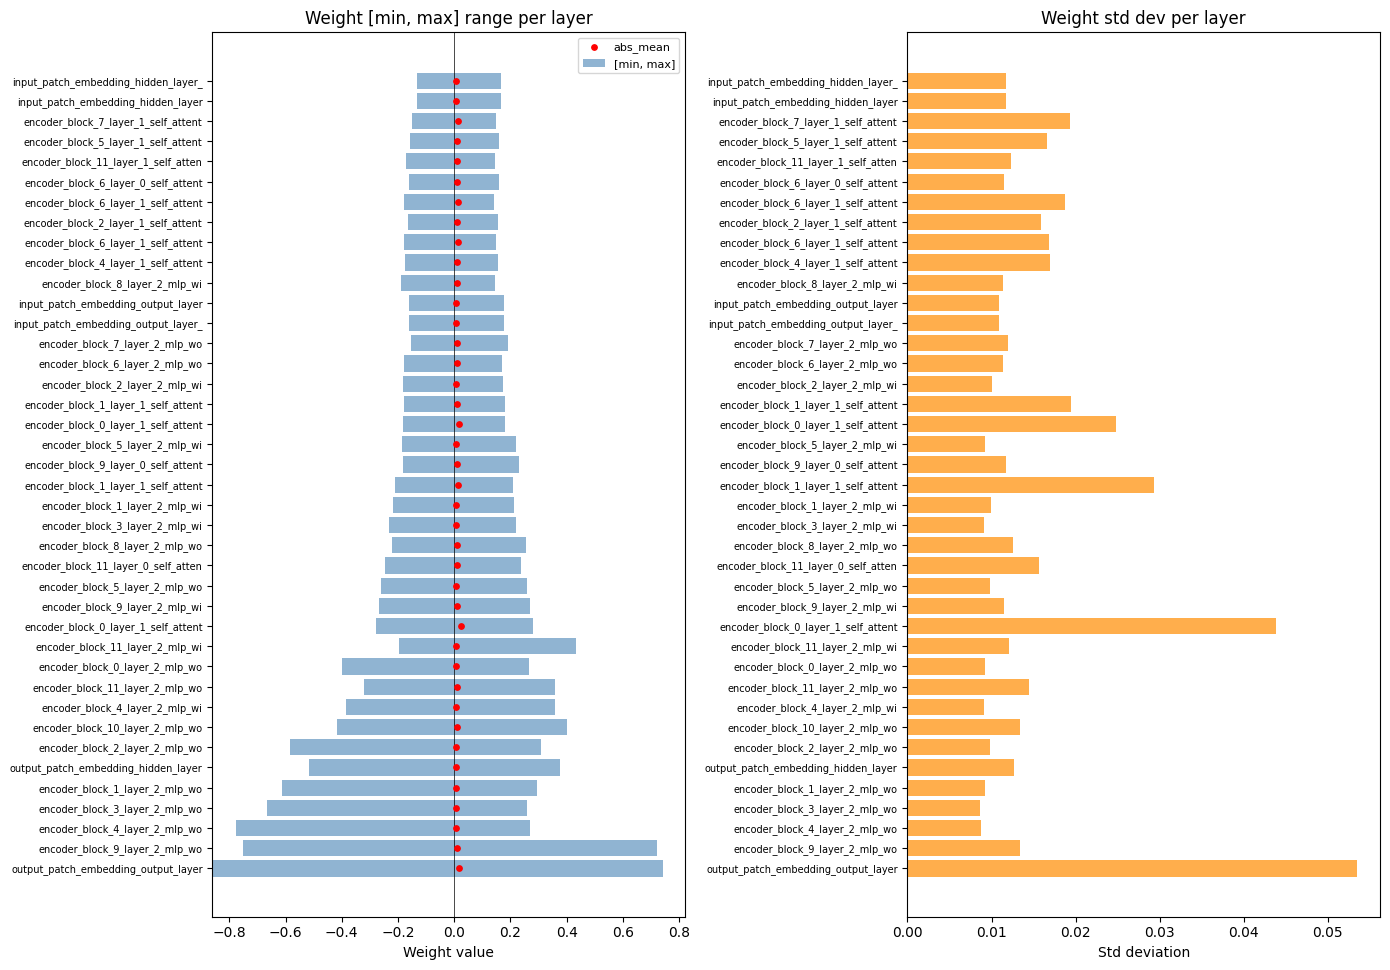

Saved weight_ranges.png


In [18]:
# ── Weight range box plot (per layer) ────────────────────────────────────────
# Show min / mean-abs / max as a horizontal band
top_w = weight_df[weight_df['entry'] == 'weight'].head(40)  # weight params only

if len(top_w) == 0:
    top_w = weight_df.head(40)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(top_w) * 0.22 + 1)))

# Left: min–max range bands
ax = axes[0]
y = range(len(top_w))
ax.barh(list(y), top_w['range'].values, left=top_w['w_min'].values,
        color='steelblue', alpha=0.6, label='[min, max]')
ax.scatter(top_w['abs_mean'].values, list(y), color='red', zorder=5, s=15, label='abs_mean')
ax.set_yticks(list(y))
ax.set_yticklabels([f"{r['node'][:35]}" for _, r in top_w.iterrows()], fontsize=7)
ax.set_xlabel('Weight value')
ax.set_title('Weight [min, max] range per layer')
ax.legend(fontsize=8)
ax.axvline(0, color='k', linewidth=0.5)

# Right: std dev
ax2 = axes[1]
ax2.barh(list(y), top_w['std'].values, color='darkorange', alpha=0.7)
ax2.set_yticks(list(y))
ax2.set_yticklabels([f"{r['node'][:35]}" for _, r in top_w.iterrows()], fontsize=7)
ax2.set_xlabel('Std deviation')
ax2.set_title('Weight std dev per layer')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'weight_ranges.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved weight_ranges.png')

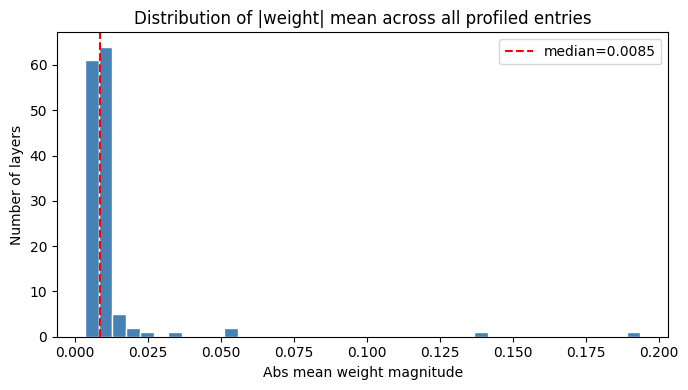

In [19]:
# ── Distribution of weight absolute means across all linear layers ───────────
fig, ax = plt.subplots(figsize=(7, 4))
vals = weight_df['abs_mean'].dropna()
ax.hist(vals, bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Abs mean weight magnitude')
ax.set_ylabel('Number of layers')
ax.set_title('Distribution of |weight| mean across all profiled entries')
ax.axvline(vals.median(), color='red', linestyle='--', label=f'median={vals.median():.4f}')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'weight_abs_mean_dist.png', dpi=150)
plt.show()

## 10. Activation statistics visualisation

In [20]:
act_df = prof_df[prof_df['kind'] == 'activation'].dropna(subset=['w_min', 'w_max']).copy()
act_df = act_df.sort_values('range', ascending=False)

print(f'Activation entries: {len(act_df)}')
print('\nTop 10 layers by activation range:')
print(act_df[['node', 'entry', 'w_min', 'w_max', 'range', 'std', 'q01', 'q99']]
      .head(10).to_string(index=False))

Activation entries: 153

Top 10 layers by activation range:
    node     entry  w_min  w_max  range        std  q01   q99
  matmul data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0
matmul_1 data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0
matmul_8 data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0
matmul_9 data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0
matmul_6 data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0
matmul_4 data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0
matmul_5 data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0
matmul_3 data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0
matmul_2 data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0
matmul_7 data_in_1    0.0  513.0  513.0 148.414834  5.0 508.0


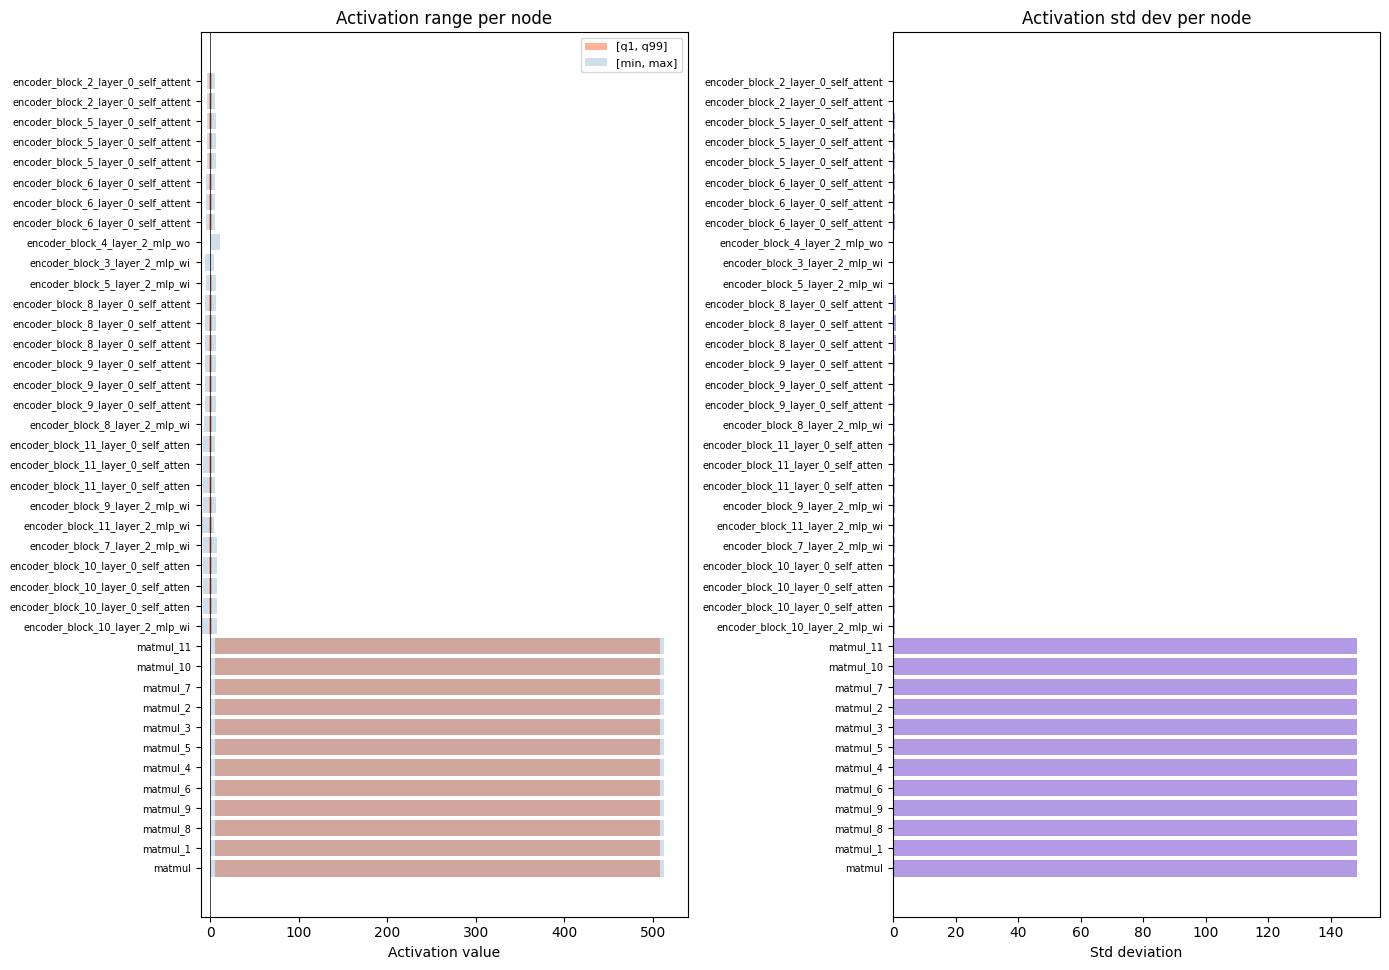

Saved activation_ranges.png


In [21]:
# ── Activation range plot ─────────────────────────────────────────────────────
top_a = act_df.head(40)

if len(top_a) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(top_a) * 0.22 + 1)))

    ax = axes[0]
    y  = range(len(top_a))
    # Draw q01–q99 inner band
    inner = top_a['q99'] - top_a['q01']
    ax.barh(list(y), inner.values, left=top_a['q01'].values,
            color='coral', alpha=0.6, label='[q1, q99]')
    # Full min-max as whiskers
    ax.barh(list(y), top_a['range'].values, left=top_a['w_min'].values,
            color='steelblue', alpha=0.25, label='[min, max]')
    ax.set_yticks(list(y))
    ax.set_yticklabels([f"{r['node'][:35]}" for _, r in top_a.iterrows()], fontsize=7)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_xlabel('Activation value')
    ax.set_title('Activation range per node')
    ax.legend(fontsize=8)

    ax2 = axes[1]
    ax2.barh(list(y), top_a['std'].values, color='mediumpurple', alpha=0.7)
    ax2.set_yticks(list(y))
    ax2.set_yticklabels([f"{r['node'][:35]}" for _, r in top_a.iterrows()], fontsize=7)
    ax2.set_xlabel('Std deviation')
    ax2.set_title('Activation std dev per node')

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'activation_ranges.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved activation_ranges.png')
else:
    print('No activation stats collected — check that target_activation_nodes matches node types in graph')

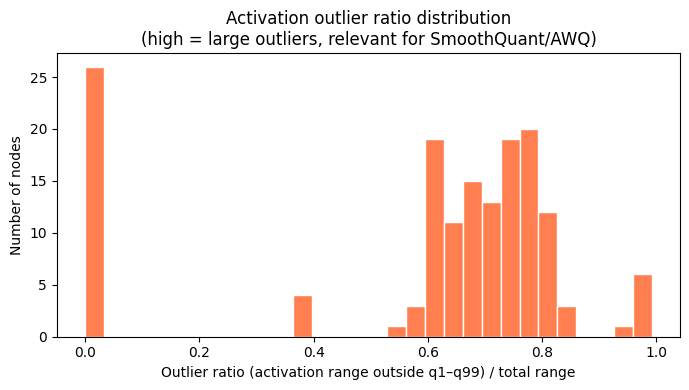

Nodes with highest outlier ratios (candidates for SmoothQuant):
                                node     entry  outlier_ratio     w_min     w_max       q01      q99
      encoder_block_4_layer_2_mlp_wo data_in_0       0.991652  0.000000 10.305232  0.000000 0.086029
      encoder_block_3_layer_2_mlp_wo data_in_0       0.988789  0.000000  6.458202  0.000000 0.072404
      encoder_block_1_layer_2_mlp_wo data_in_0       0.987244  0.000000  4.475041  0.000000 0.057085
      encoder_block_0_layer_2_mlp_wo data_in_0       0.979806  0.000000  2.373981  0.000000 0.047940
      encoder_block_2_layer_2_mlp_wo data_in_0       0.976948  0.000000  3.610922  0.000000 0.083239
      encoder_block_9_layer_2_mlp_wo data_in_0       0.964960  0.000000  7.975327  0.000000 0.279454
input_patch_embedding_output_layer_1 data_in_0       0.938323  0.000000  0.173761  0.000000 0.010717
      encoder_block_0_layer_2_mlp_wi data_in_0       0.854020 -2.992128  3.487476 -0.429322 0.516572
      encoder_block_5_layer

In [22]:
# ── Outlier ratio: fraction of activation range outside [q1, q99] ────────────
if len(act_df) > 0:
    act_df = act_df.copy()
    act_df['outlier_range'] = (act_df['range'] - (act_df['q99'] - act_df['q01'])).clip(lower=0)
    act_df['outlier_ratio'] = act_df['outlier_range'] / act_df['range'].replace(0, float('nan'))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(act_df['outlier_ratio'].dropna(), bins=30, color='coral', edgecolor='white')
    ax.set_xlabel('Outlier ratio (activation range outside q1–q99) / total range')
    ax.set_ylabel('Number of nodes')
    ax.set_title('Activation outlier ratio distribution\n(high = large outliers, relevant for SmoothQuant/AWQ)')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'activation_outlier_ratio.png', dpi=150)
    plt.show()

    print('Nodes with highest outlier ratios (candidates for SmoothQuant):')
    print(act_df.sort_values('outlier_ratio', ascending=False)
          [['node', 'entry', 'outlier_ratio', 'w_min', 'w_max', 'q01', 'q99']]
          .head(10).to_string(index=False))

## 11. Weight vs activation range comparison

High weight range relative to activation range → quantization errors will be weight-dominated (favours AWQ/GPTQ).  
High activation range relative to weight range → SmoothQuant-style activation smoothing will help.

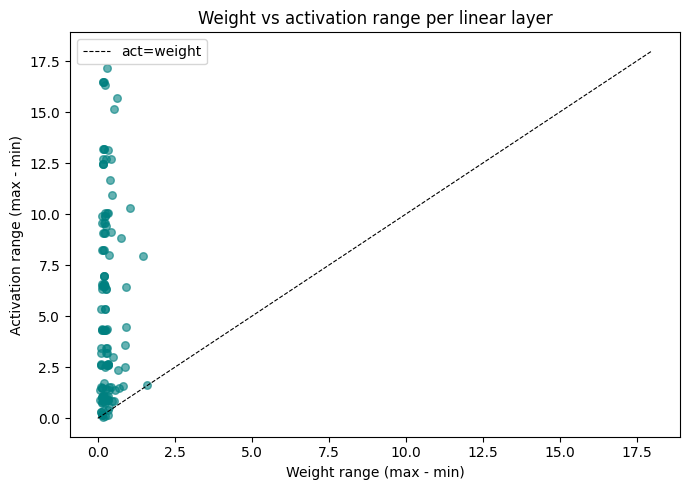


Layers where activation range >> weight range (SmoothQuant candidates):
                                           range_weight  range_act  act_weight_range_ratio
node                                                                                      
encoder_block_10_layer_0_self_attention_k      0.162670  16.476587              101.288718
encoder_block_10_layer_0_self_attention_q      0.170807  16.476587               96.463184
encoder_block_10_layer_0_self_attention_v      0.189070  16.476587               87.145352
encoder_block_8_layer_0_self_attention_q       0.155481  12.475452               80.237823
encoder_block_11_layer_0_self_attention_q      0.167778  13.182477               78.571146
encoder_block_9_layer_0_self_attention_v       0.163504  12.692157               77.626107
encoder_block_2_layer_0_self_attention_v       0.128346   9.579160               74.635174
encoder_block_8_layer_0_self_attention_k       0.171996  12.475452               72.533511
encoder_block_8_l

In [23]:
# Match weight and activation entries by node name
w_by_node = (weight_df[weight_df['entry'] == 'weight']
             .groupby('node')[['range', 'abs_mean', 'std']].mean())
a_by_node = (act_df[act_df['entry'] == 'data_in_0']
             .groupby('node')[['range', 'abs_mean', 'std']].mean()
             if 'data_in_0' in act_df['entry'].values
             else act_df.groupby('node')[['range', 'abs_mean', 'std']].mean())

compare_df = w_by_node.join(a_by_node, lsuffix='_weight', rsuffix='_act', how='inner')
compare_df['act_weight_range_ratio'] = compare_df['range_act'] / compare_df['range_weight'].replace(0, float('nan'))

if len(compare_df) > 0:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(compare_df['range_weight'], compare_df['range_act'],
               alpha=0.6, s=30, color='teal')
    lim = max(compare_df['range_weight'].max(), compare_df['range_act'].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='act=weight')
    ax.set_xlabel('Weight range (max - min)')
    ax.set_ylabel('Activation range (max - min)')
    ax.set_title('Weight vs activation range per linear layer')
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'weight_vs_act_range.png', dpi=150)
    plt.show()

    print('\nLayers where activation range >> weight range (SmoothQuant candidates):')
    print(compare_df.sort_values('act_weight_range_ratio', ascending=False)
          [['range_weight', 'range_act', 'act_weight_range_ratio']]
          .head(10).to_string())
else:
    print('Not enough matching weight/activation nodes for comparison')

## 12. FLOPs estimate

Estimate GFLOPs using parameter shapes from the graph metadata.  
For a linear layer of shape `[out, in]` with input `[B, T, in]`: FLOPs ≈ `2 × B × T × in × out`.

In [24]:
flop_rows = []
for node in mg.fx_graph.nodes:
    if node.op != 'call_module':
        continue
    try:
        mase_op  = get_mase_op(node)
        module   = node.meta['mase'].module
        common   = node.meta['mase'].parameters.get('common', {})
        args_m   = common.get('args', {})

        # Get the data_in_0 shape
        in_shape = None
        for k, v in args_m.items():
            if 'data_in' in k and isinstance(v, dict):
                in_shape = v.get('shape')
                break

        if in_shape is None:
            continue

        flops = None
        if mase_op == 'linear' and hasattr(module, 'weight'):
            out_feat, in_feat = module.weight.shape
            batch_tokens = 1
            for d in in_shape[:-1]:  # all dims except last
                batch_tokens *= d
            flops = 2 * batch_tokens * in_feat * out_feat

        if flops is not None:
            flop_rows.append({
                'node':      node.name,
                'mase_op':   mase_op,
                'in_shape':  in_shape,
                'flops':     flops,
                'gflops':    flops / 1e9,
            })
    except Exception:
        pass

flop_df = pd.DataFrame(flop_rows).sort_values('flops', ascending=False)
total_gflops = flop_df['gflops'].sum()
print(f'Estimated total GFLOPs (linear layers): {total_gflops:.3f}')
print(f'\nTop 20 most expensive layers:')
print(flop_df.head(20)[['node', 'mase_op', 'in_shape', 'gflops']].to_string(index=False))

Estimated total GFLOPs (linear layers): 238.068

Top 20 most expensive layers:
                           node mase_op       in_shape   gflops
 encoder_block_0_layer_2_mlp_wi  linear  [2, 514, 768] 4.850713
 encoder_block_9_layer_2_mlp_wi  linear  [2, 514, 768] 4.850713
 encoder_block_0_layer_2_mlp_wo  linear [2, 514, 3072] 4.850713
 encoder_block_1_layer_2_mlp_wo  linear [2, 514, 3072] 4.850713
 encoder_block_1_layer_2_mlp_wi  linear  [2, 514, 768] 4.850713
 encoder_block_3_layer_2_mlp_wi  linear  [2, 514, 768] 4.850713
 encoder_block_3_layer_2_mlp_wo  linear [2, 514, 3072] 4.850713
 encoder_block_2_layer_2_mlp_wo  linear [2, 514, 3072] 4.850713
 encoder_block_2_layer_2_mlp_wi  linear  [2, 514, 768] 4.850713
 encoder_block_5_layer_2_mlp_wi  linear  [2, 514, 768] 4.850713
 encoder_block_4_layer_2_mlp_wo  linear [2, 514, 3072] 4.850713
 encoder_block_4_layer_2_mlp_wi  linear  [2, 514, 768] 4.850713
 encoder_block_8_layer_2_mlp_wo  linear [2, 514, 3072] 4.850713
 encoder_block_7_layer_2_

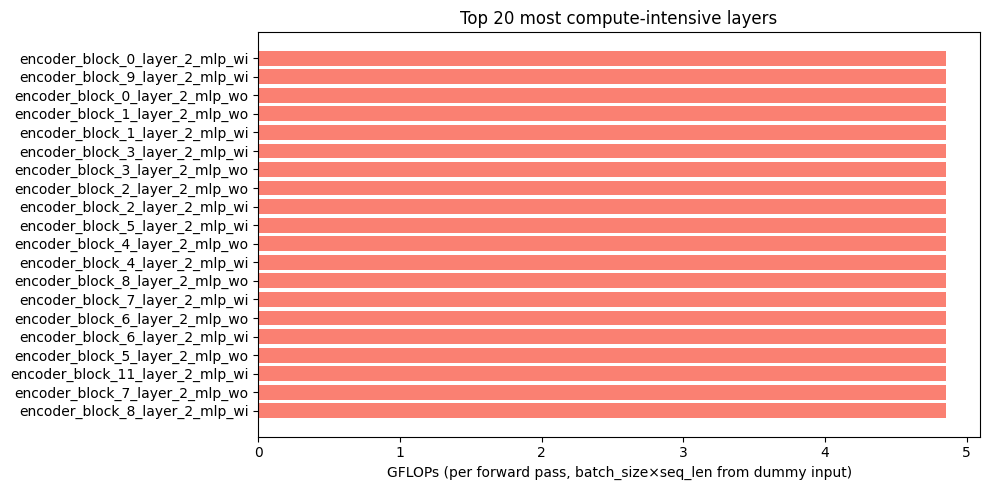

In [25]:
# ── FLOPs waterfall: top 20 layers ───────────────────────────────────────────
if len(flop_df) > 0:
    top_f = flop_df.head(20)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top_f['node'].values[::-1], top_f['gflops'].values[::-1], color='salmon')
    ax.set_xlabel('GFLOPs (per forward pass, batch_size×seq_len from dummy input)')
    ax.set_title('Top 20 most compute-intensive layers')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'flops_breakdown.png', dpi=150)
    plt.show()

## 13. Summary table

In [26]:
print('=' * 70)
print('CHRONOS-2 PROFILING SUMMARY')
print('=' * 70)
print(f'  Total parameters:         {total_params:>12,}')
print(f'  Model size (FP32):        {size_fp32_mb:>10.1f} MB')
print(f'  Model size (INT8):        {size_int8_mb:>10.1f} MB')
print(f'  Graph nodes:              {len(all_nodes):>12}')
print(f'  call_module nodes:        {sum(1 for n in all_nodes if n.op=="call_module"):>12}')
print(f'  Est. GFLOPs (linear):     {total_gflops:>12.3f}')
print()
if len(weight_df) > 0:
    print(f'  Weight entries profiled:  {len(weight_df):>12}')
    print(f'  Median weight range:      {weight_df["range"].median():>12.4f}')
    print(f'  Max weight range:         {weight_df["range"].max():>12.4f}')
    print(f'    -> in node:             {weight_df.loc[weight_df["range"].idxmax(), "node"]}')
if len(act_df) > 0:
    print(f'  Activation entries:       {len(act_df):>12}')
    print(f'  Median activation range:  {act_df["range"].median():>12.4f}')
    print(f'  Max activation range:     {act_df["range"].max():>12.4f}')
    print(f'    -> in node:             {act_df.loc[act_df["range"].idxmax(), "node"]}')
print('=' * 70)
print(f'Artifacts saved to: {OUTPUT_DIR.resolve()}')

CHRONOS-2 PROFILING SUMMARY
  Total parameters:          119,477,664
  Model size (FP32):             455.8 MB
  Model size (INT8):             113.9 MB
  Graph nodes:                      2034
  call_module nodes:                 198
  Est. GFLOPs (linear):          238.068

  Weight entries profiled:           138
  Median weight range:            0.2410
  Max weight range:               1.6005
    -> in node:             output_patch_embedding_output_layer
  Activation entries:                153
  Median activation range:        4.3084
  Max activation range:         513.0000
    -> in node:             matmul
Artifacts saved to: C:\Users\User\Documents\Coding\mase\chronos2\artifacts\profiling
